# Machine Learning: Credit Score Classification
#### Mohamed Saleh Abdelsalam - 233656 - AI

### Content
    1. Data Overview and Feature Selection
    2. Train/Test Split
    3. Model Training
        3.1 Logistic Regression
        3.2 KNN
        3.3 SVM
        3.4 Decision Tree
    4. SMOTE for Class Imbalance
        4.1 Logistic Regression
        4.2 KNN
        4.3 SVM
        4.4 Decision Tree
    5. Conclusion

## 1. Data Overview and Feature Selection
Over the years, a global finance company has collected basic bank details and gathered anonymized credit-related information that the dataset represents. Each record corresponds to a single customer’s financial and demographic profile for a given month, with the goal of predicting their credit score category (Good, Standard, or Poor). This problem falls under the supervised machine learning classification domain, where the target variable is Credit_Score.

<b>URL:</b> https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data?select=train.csv

Import all important libraries.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder ,StandardScaler , PolynomialFeatures , MinMaxScaler
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import learning_curve, validation_curve
import matplotlib.pyplot as plt
import numpy as np


- Evaluation Metrics Functions

1. Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_classification(model, X_test, y_test):

    y_pred = model.predict(X_test)

    # Classification Report
    print("\n===== Classification Report (Test Data) =====")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n===== Confusion Matrix =====")
    print(cm)

    # Plot heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


2. Learning Curve
uses 5 folds cross validation.

not optimal for computational heavy models like SVC.

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_train, y_train):
   
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation Score')
    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()


3. ROC Curve

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(model, X_test, y_test):

    # Binarize labels
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Predict probabilities
    y_score = model.predict_proba(X_test)

    n_classes = y_score.shape[1]
    plt.figure(figsize=(8,6))

    # Plot ROC curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0,1], [0,1], 'k--')
    plt.title("ROC Curve (One-vs-Rest)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


4. Parameter Curve

- For lr (C) and KNN (n_neighbor)
- using grid search with 5 fold cross-validation method.
- Grid search tries all values or combinations of a hyperparameter to find the best one.
- for each hyperparameter, it used 5 fold CV, each fold is used once as a validation set while the others are used for training.
- It provides the average validation score for each hyperparameter.
- The hyperparameter with the highest average score is selected as best.

In [5]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

def plot_grid_search_curve(model, X_train, y_train, X_test, y_test, param_name, param_range, cv=5, scoring='accuracy', log_scale=True):
    
    # Prepare parameter grid
    param_grid = {param_name: param_range}
    
    # Grid search with cross-validation
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    # Extract mean train and validation scores
    train_scores = grid.cv_results_['mean_train_score']
    val_scores = grid.cv_results_['mean_test_score']
    
    # Plot
    plt.figure(figsize=(8,6))
    if log_scale:
        plt.semilogx(param_range, train_scores, marker='o', label='Training Accuracy')
        plt.semilogx(param_range, val_scores, marker='o', label='Validation Accuracy')
    else:
        plt.plot(param_range, train_scores, marker='o', label='Training Accuracy')
        plt.plot(param_range, val_scores, marker='o', label='Validation Accuracy')
        
    plt.title(f'Grid Search Curve for {param_name}')
    plt.xlabel(param_name)
    plt.ylabel(scoring.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Best model and its performance
    best_model = grid.best_estimator_
    print("Best Hyperparameter:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    print("Accuracy on Training Set:", accuracy_score(y_train, y_train_pred))
    print("Accuracy on Test Set:", accuracy_score(y_test, y_test_pred))
    
    return best_model


Read the data

In [329]:
path=r"C:\Users\Mohamed Saleh\Documents\Documents\Computer Science\Artificial Intelligence\Semester 7\Machine Learning\Assignment 1\233656_Classification\cleaned_train.csv"
df=pd.read_csv(path)
df

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Months_Delayed,Spending_Level,Payment_Value,Occupation_0,Occupation_1,Occupation_2,Occupation_3
0,23,19114,"1,592.83",3,4,1.10,4,12.34,11.00,4.00,2.00,809,31.94,19.93,0,49.57,4.77,2.00,284.00,2.00,0,1,0,0,0,0,1
1,23,19114,"1,592.83",3,4,1.10,4,4.00,6.00,4.00,2.00,809,31.38,22.00,0,49.57,5.29,0.00,223.00,2.00,0,1,2,0,0,0,1
2,23,19114,"1,824.84",3,4,1.10,4,12.34,11.00,4.00,2.00,809,24.80,22.00,0,49.57,3.71,4.00,341.00,2.00,0,0,1,0,0,0,1
3,23,19114,"1,824.84",3,4,1.10,4,8.00,11.00,4.00,2.00,809,22.54,22.00,0,49.57,5.18,0.00,244.00,2.00,0,1,2,0,0,0,1
4,23,19114,"1,824.84",3,4,1.10,4,6.00,11.00,4.00,2.00,809,23.93,19.93,0,49.57,3.18,4.00,358.00,1.00,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27714,39,120009,"10,242.78",5,1,1.95,4,1.00,6.00,0.00,2.00,446,37.37,28.00,0,230.53,5.65,4.00,758.00,1.00,0,0,1,0,0,0,1
27715,40,120009,"10,242.78",5,1,1.95,4,0.00,6.00,0.00,2.00,446,33.62,29.00,0,230.53,5.68,4.00,749.00,1.00,0,0,1,0,0,0,1
27716,40,120009,"10,242.78",5,1,1.95,4,3.00,6.00,0.00,2.00,446,40.49,29.00,0,230.53,-inf,3.00,460.00,1.00,0,0,2,0,0,0,1
27717,24,59868,"5,111.08",4,7,2.20,4,10.00,4.00,4.00,2.00,417,31.70,28.00,0,104.62,5.60,3.00,395.00,1.00,0,0,2,0,1,1,1


#### Feature Selection: Filter Method

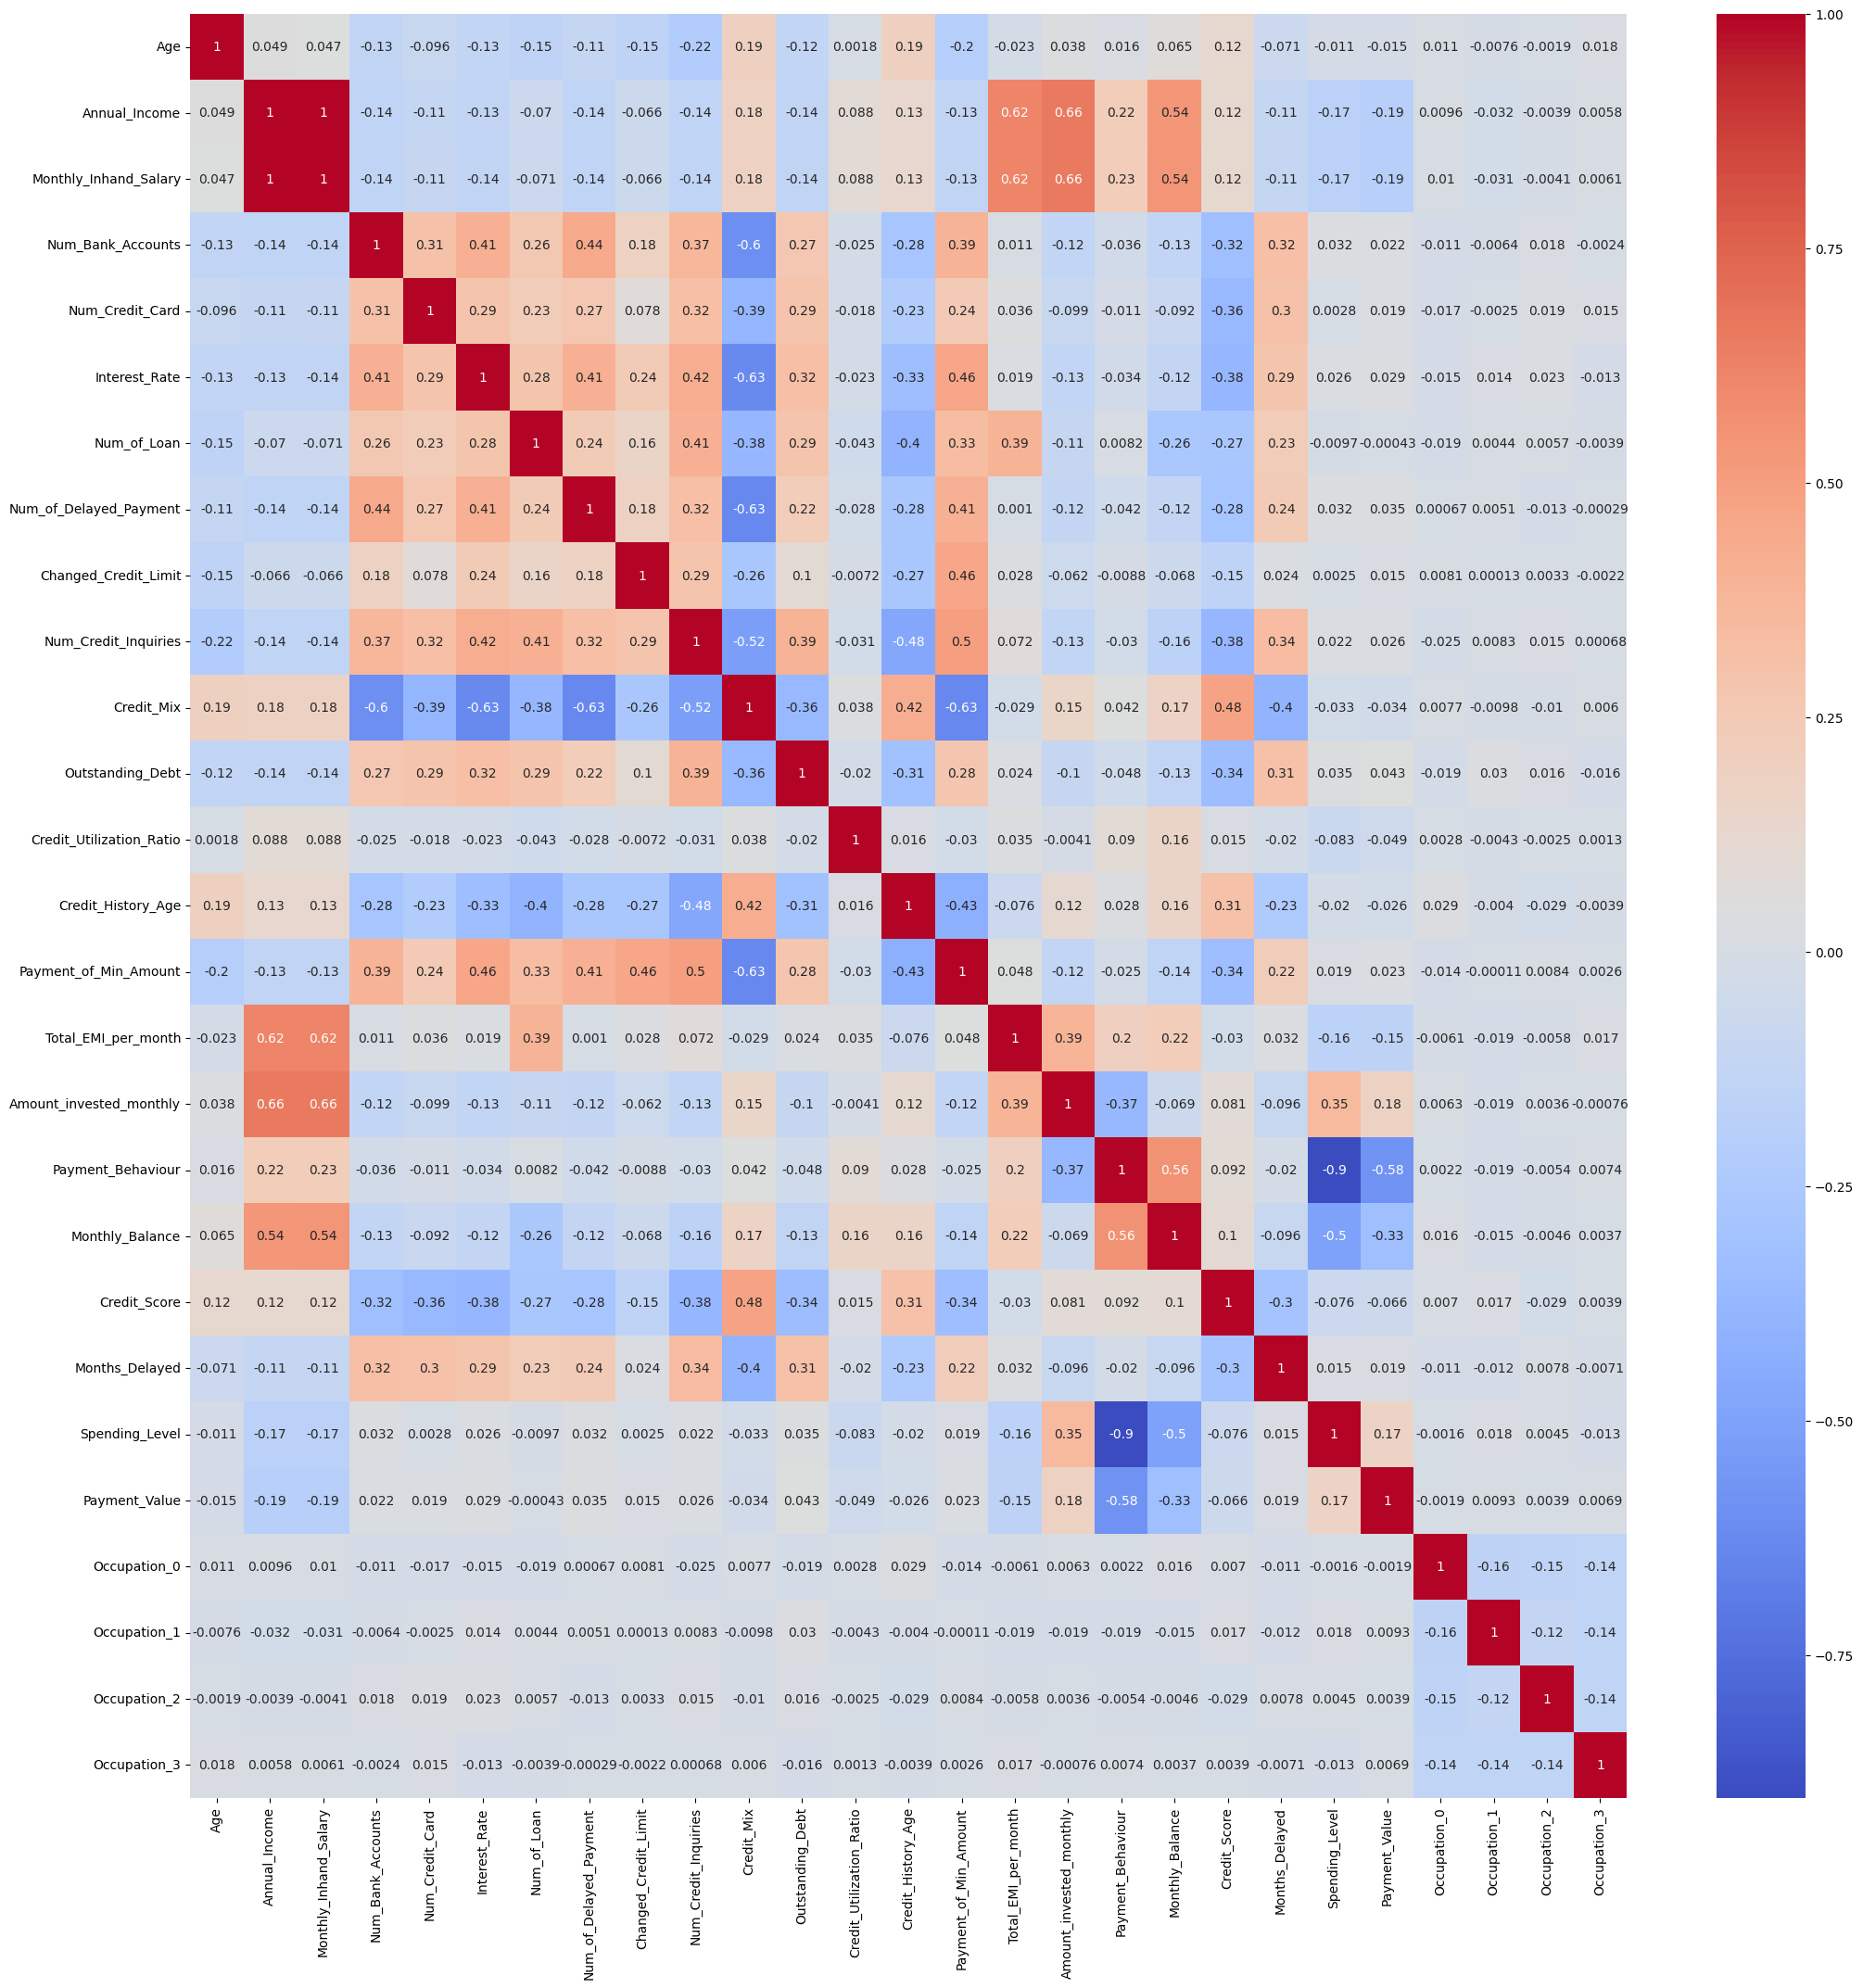

In [331]:
corrmat = df.corr()

plt.figure(figsize=(25,25))
sns.heatmap(corrmat, annot=True, cmap='coolwarm')
plt.show()


Correlation can't detect non linear relationships.

However, Spearman method detect monotonic associations

In [342]:
corr = df.corr(method='spearman')['Credit_Score'].sort_values(ascending=False) 
corr

Credit_Score                1.00
Credit_Mix                  0.47
Credit_History_Age          0.31
Annual_Income               0.13
Monthly_Inhand_Salary       0.12
Monthly_Balance             0.12
Age                         0.12
Payment_Behaviour           0.09
Amount_invested_monthly     0.07
Occupation_1                0.02
Credit_Utilization_Ratio    0.01
Occupation_0                0.01
Occupation_3                0.00
Total_EMI_per_month        -0.03
Occupation_2               -0.03
Payment_Value              -0.07
Spending_Level             -0.08
Changed_Credit_Limit       -0.14
Num_of_Loan                -0.23
Num_of_Delayed_Payment     -0.27
Months_Delayed             -0.30
Num_Bank_Accounts          -0.31
Num_Credit_Card            -0.32
Outstanding_Debt           -0.33
Payment_of_Min_Amount      -0.34
Num_Credit_Inquiries       -0.36
Interest_Rate              -0.41
Name: Credit_Score, dtype: float64

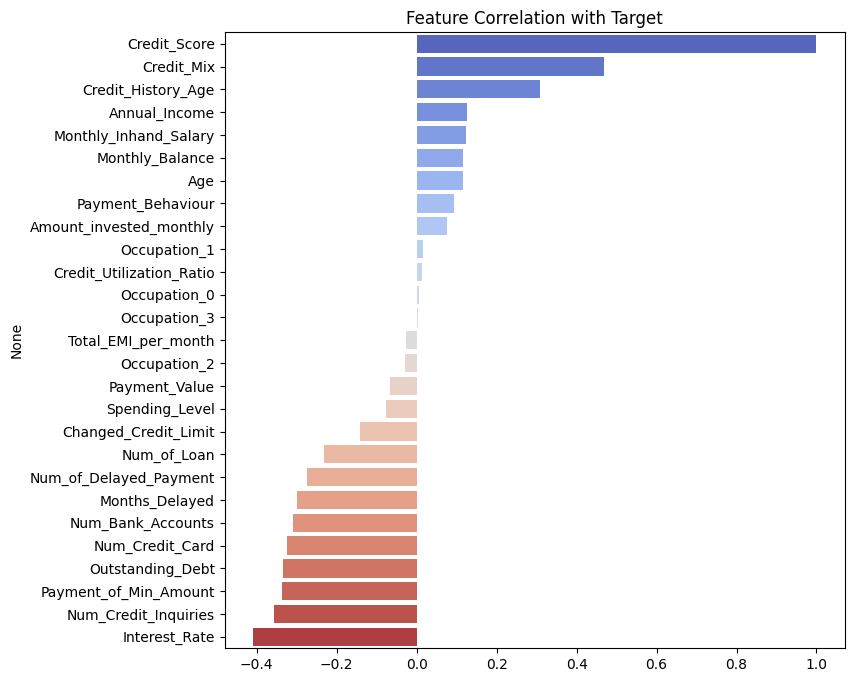

In [343]:
plt.figure(figsize=(8,8))
sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
plt.title("Feature Correlation with Target")
plt.show()

Weak Predictors ( |ρ| < 0.1 )

so we keep: Credit_Mix, Credit_History_Age, Interest_Rate, Num_Credit_Inquiries,
Payment_of_Min_Amount, Outstanding_Debt, Num_Credit_Card,
Num_Bank_Accounts, Months_Delayed, Annual_Income, Monthly_Inhand_Salary, Monthly_Balance, Age

and drop others

Spearman correlation, ρ, measures monotonic association between a feature and the target.

ρ ranges from -1 to 1:

Close to ±1 : strong monotonic relationship

Close to 0 : weak or no monotonic relationship

In [344]:
weak_features = [
    'Payment_Behaviour',
    'Amount_invested_monthly',
    'Occupation_0',
    'Occupation_1',
    'Occupation_2',
    'Occupation_3',
    'Payment_Value',
    'Spending_Level',
    'Total_EMI_per_month'
]


df= df.drop(columns=weak_features)

print("Remaining features:")
print(df.columns)


Remaining features:
Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Monthly_Balance', 'Credit_Score',
       'Months_Delayed'],
      dtype='object')


### 2. Train Test Split

- Split features and target
- Train-test split (80% - 20%)
-  Replace infinity with Nan
- Impute Nans with mean
- Scale features. Normalization.

In [345]:
#Input x and Output y
x , y = df.drop(['Credit_Score'] , axis=1) , df[['Credit_Score']]

#stratify=y to ensure credit score class appears in the same proption
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=10 , stratify=y)

#search for impossible data and replace it with nulls
x_train = np.where(np.isinf(x_train), np.nan, x_train)
x_test = np.where(np.isinf(x_test), np.nan, x_test)

# Check for NaNs and replace them with the column mean (or use imputation)
x_train = np.nan_to_num(x_train, nan=np.nanmean(x_train))
x_test = np.nan_to_num(x_test, nan=np.nanmean(x_test))

# Initialize StandardScaler
scl = StandardScaler()

# Apply StandardScaler
x_train = scl.fit_transform(x_train) #fit scalar on training data only
x_test = scl.transform(x_test) #transform test data using training scaler

### 3. Model Training

#### 3.1 Logistic Regression

Parameter curve to choose the best parameter

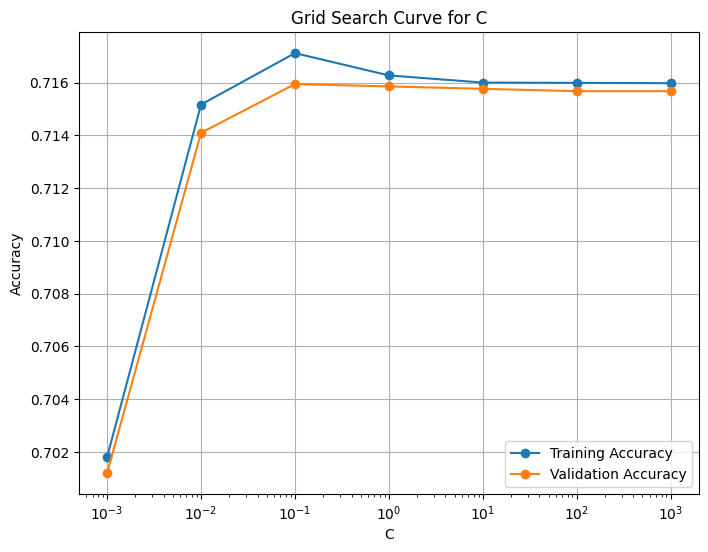

Best Hyperparameter: {'C': np.float64(0.1)}
Best CV Score: 0.7159413754227734
Accuracy on Training Set: 0.7170687711386696
Accuracy on Test Set: 0.7195165945165946


,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0.1)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [290]:
from sklearn.linear_model import LogisticRegression
param_range = np.logspace(-3, 3, 7)

plot_grid_search_curve(
    model=LogisticRegression(),
    X_train=x_train,
    y_train=y_train,
    X_test=x_test,
    y_test=y_test,
    param_name='C',
    param_range=param_range,
    cv=5
)


How model performance changes as a hyperparameter varies.

at C=0.1 was the best regularization strength

- Fit the lr model
- Make predictions.


In [291]:
lr = LogisticRegression(C=0.1)

lr.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [292]:
y_train_pred = lr.predict(x_train) #data it was trained on
y_test_pred =  lr.predict(x_test) #on unseen data

In [293]:
print(f"Score of Train: {lr.score(x_train , y_train)}")
print(f"Score of Test: {lr.score(x_test , y_test)}")

Score of Train: 0.7170687711386696
Score of Test: 0.7195165945165946



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.73      0.48      0.58      1159
         1.0       0.78      0.82      0.80      3288
         2.0       0.56      0.67      0.61      1097

    accuracy                           0.72      5544
   macro avg       0.69      0.66      0.66      5544
weighted avg       0.72      0.72      0.72      5544




===== Confusion Matrix =====
[[ 553  430  176]
 [ 195 2698  395]
 [  11  348  738]]


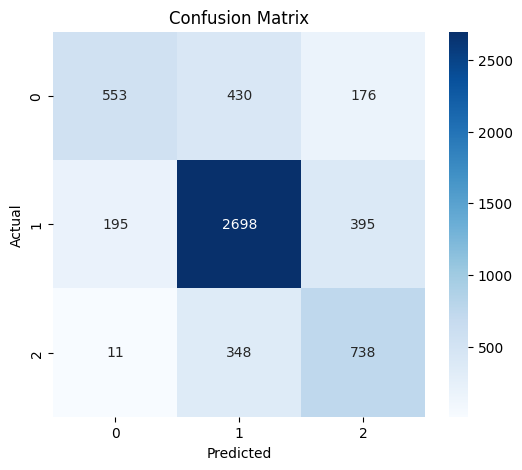

In [294]:
evaluate_model_classification(lr, x_test, y_test)

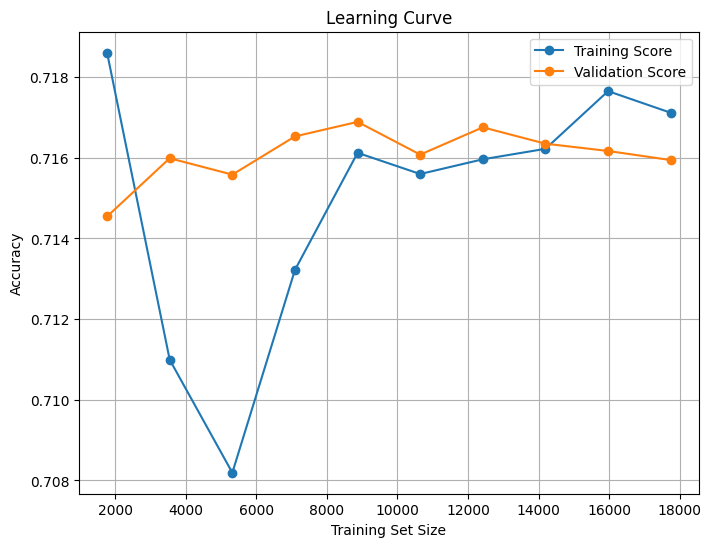

In [295]:
plot_learning_curve(lr, x_train, y_train)

Good fit, Training and Validation curves converges.

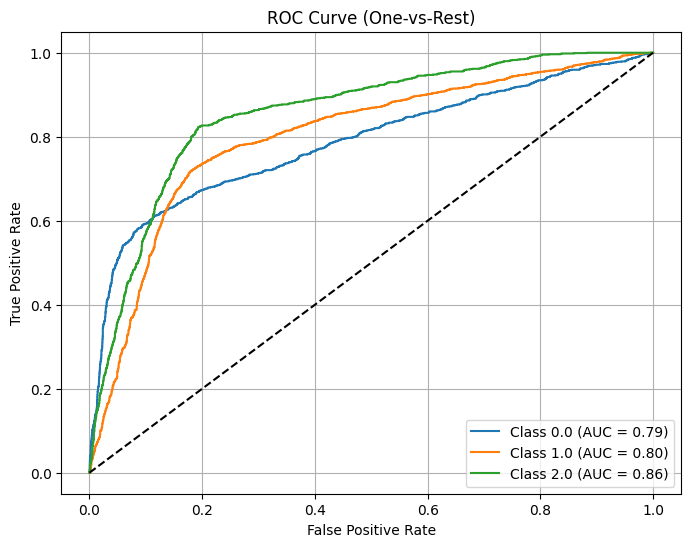

In [296]:
plot_multiclass_roc(lr, x_test, y_test)

Poor (0.79): Model can distinguish poor credit reasonably well, but there’s some confusion with Standard/Good.

Standard (0.80): Slightly better than Poor.

Good (0.86): Model distinguishes good credit clearly from the other two classes.

**Interpretation**
0: Poor
1: Standard
2: Good
-  Overall, accuracy: 72%
- The model performs best on class 1 (Standard), and worst on class 2 (Good).
- These results happened because the data is imbalanced.
- Recall: The model struggles with the poor and good credit customers
- Many class 0 and class 2 points are incorrectly predicted as class 1

#### 3.2 K-Nearest Neighbor (KNN)

find the best parameter value.

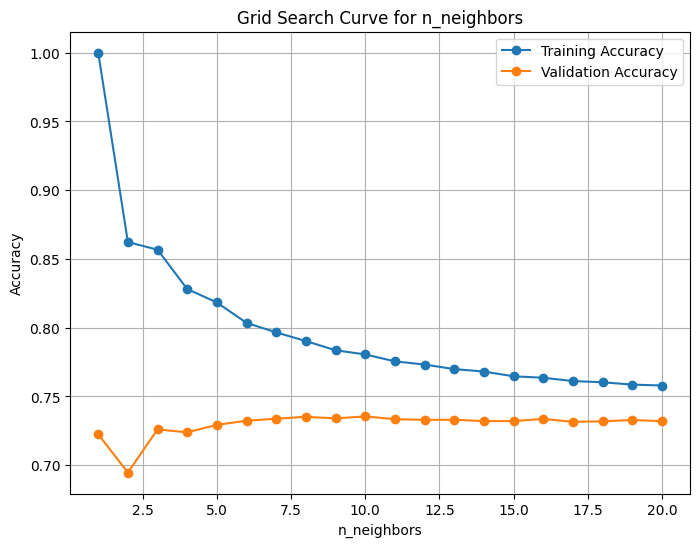

Best Hyperparameter: {'n_neighbors': 10}
Best CV Score: 0.7353325817361893
Accuracy on Training Set: 0.7862908680947013
Accuracy on Test Set: 0.73989898989899


,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [297]:
param_range = list(range(1, 21))
plot_grid_search_curve(
    model=KNeighborsClassifier(),
    X_train=x_train,
    y_train=y_train,
    X_test=x_test,
    y_test=y_test,
    param_name='n_neighbors',
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    log_scale=False  # no need for log scale for integer neighbors
)

fit the model

In [298]:
knnc =KNeighborsClassifier(n_neighbors=10)
knnc.fit(x_train , y_train)


,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [299]:
print(f"Score of Train: {knnc.score(x_train , y_train)}")
print(f"Score of Test: {knnc.score(x_test , y_test)}")

Score of Train: 0.7862908680947013
Score of Test: 0.73989898989899


classification report:


===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.71      0.63      0.67      1159
         1.0       0.78      0.83      0.81      3288
         2.0       0.62      0.59      0.60      1097

    accuracy                           0.74      5544
   macro avg       0.70      0.68      0.69      5544
weighted avg       0.74      0.74      0.74      5544


===== Confusion Matrix =====
[[ 727  329  103]
 [ 266 2731  291]
 [  34  419  644]]


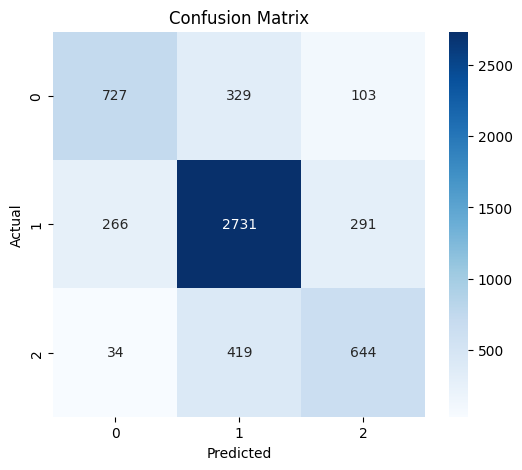

In [300]:
evaluate_model_classification(knnc, x_test, y_test)

Learning curve

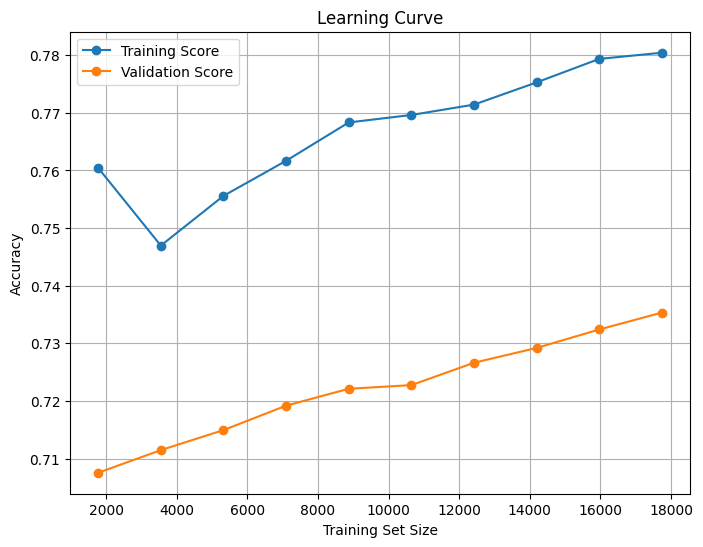

In [301]:
plot_learning_curve(knnc,x_train, y_train)

- good fitted model that is slightly tending to over fit. (Mild overfitting)
- KNN is non parametric and memorizes training data based on neighbors.

ROC Curve

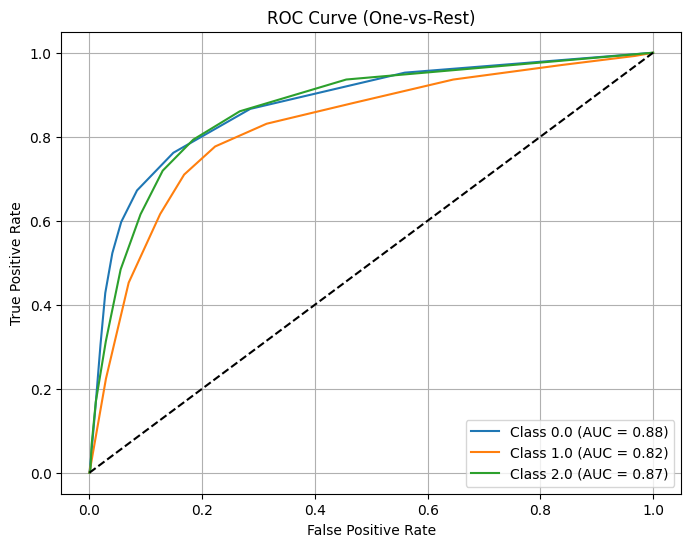

In [302]:
plot_multiclass_roc(knnc, x_test, y_test)

- The KNN model overall discriminates classes quite well (all AUCs >0.8).
- The slightly lower AUC for Standard means that this class is harder to separate than Poor or Good.

**Interpretation**
- Overall, accuracy = 74%
- Standard is the best predicted class, while poor and good often misclassified as standard.
- KNN is based on neighbors, classes that are close in feature space get confused.
- Standard is the majority class in the dataset -> KNN predicts it correctly often (high recall, high F1). However, the model may not separate Standard well from Poor or Good in terms of probability scores (AUC is lower).

#### 3.3 Support Vector Classifier (SVC)

Due to computational constraints with SVC on the full dataset, hyperparameters were chosen manually based on common recommended values, rather than performing an exhaustive grid search and randomized search.

Learning curve function for SVC models.

In [303]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def learning_curve_svc(model, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 5), cv=3, subset_size=None):
    if subset_size:
        X_train = X_train[:subset_size]
        y_train = y_train[:subset_size]

    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes_abs, train_mean, 'o-', label='Training Accuracy')
    plt.plot(train_sizes_abs, val_mean, 'o-', label='Validation Accuracy')
    plt.title(f"Learning Curve ({model.kernel if hasattr(model,'kernel') else 'SVC'})")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()


In [304]:
svc = SVC(kernel='linear',probability=False , C=1)
svc.fit(x_train , y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [305]:
print(f"Score of Train: {svc.score(x_train , y_train)}")
print(f"Score of Test: {svc.score(x_test , y_test)}")

Score of Train: 0.714859075535513
Score of Test: 0.7133838383838383



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.73      0.48      0.58      1159
         1.0       0.78      0.82      0.80      3288
         2.0       0.56      0.67      0.61      1097

    accuracy                           0.72      5544
   macro avg       0.69      0.66      0.66      5544
weighted avg       0.72      0.72      0.72      5544


===== Confusion Matrix =====
[[ 553  430  176]
 [ 195 2698  395]
 [  11  348  738]]


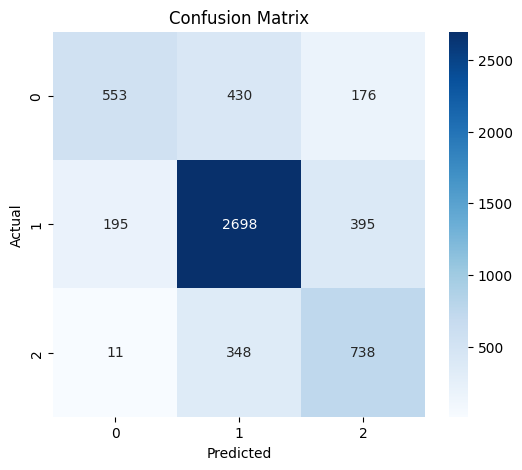

In [306]:
evaluate_model_classification(lr, x_test, y_test)

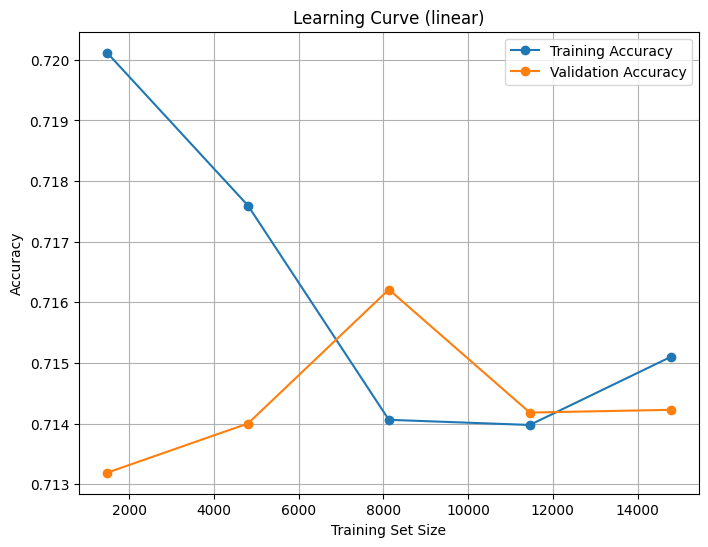

In [307]:
fast_learning_curve_svc(svc, x_train, y_train)

In [308]:
svc_poly = SVC(kernel='poly')
svc_poly.fit(x_train , y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [309]:
print(f"Score of Train: {svc_poly.score(x_train , y_train)}")
print(f"Score of Test: {svc_poly.score(x_test , y_test)}")

Score of Train: 0.7417812852311161
Score of Test: 0.7352092352092352



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.77      0.52      0.62      1159
         1.0       0.80      0.81      0.81      3288
         2.0       0.56      0.73      0.63      1097

    accuracy                           0.74      5544
   macro avg       0.71      0.69      0.69      5544
weighted avg       0.75      0.74      0.73      5544


===== Confusion Matrix =====
[[ 605  365  189]
 [ 175 2665  448]
 [   3  288  806]]


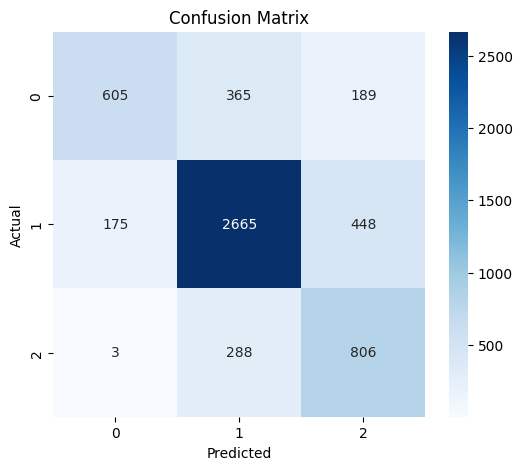

In [310]:
evaluate_model_classification(svc_poly, x_test, y_test)

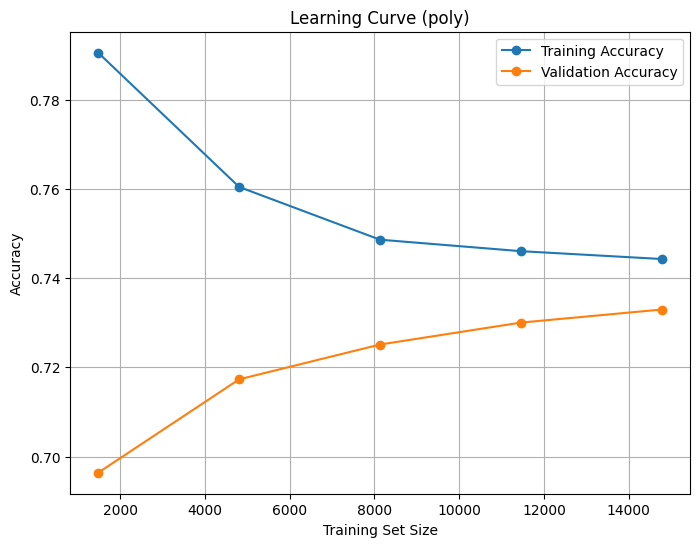

In [311]:
learning_curve_svc(svc_poly, x_train, y_train)

In [312]:
svc_poly_c = SVC(kernel='poly' , degree=3 , C=5,coef0=0.05)
svc_poly_c.fit(x_train , y_train)

,C,5
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.05
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [313]:
print(f"Score of Train: {svc_poly_c.score(x_train , y_train)}")
print(f"Score of Test: {svc_poly_c.score(x_test , y_test)}")

Score of Train: 0.7510259301014656
Score of Test: 0.7411616161616161



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.77      0.56      0.65      1159
         1.0       0.82      0.81      0.81      3288
         2.0       0.56      0.74      0.64      1097

    accuracy                           0.74      5544
   macro avg       0.71      0.70      0.70      5544
weighted avg       0.75      0.74      0.74      5544


===== Confusion Matrix =====
[[ 649  320  190]
 [ 191 2650  447]
 [   7  280  810]]


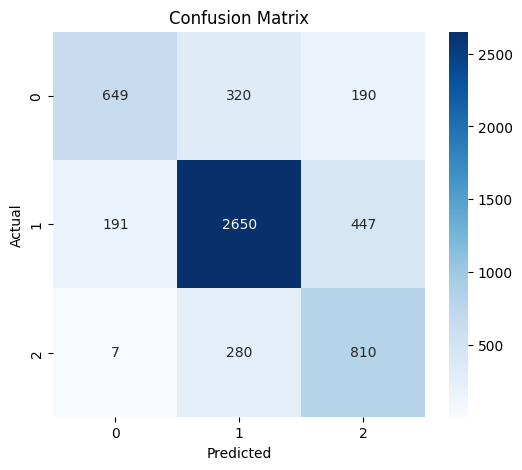

In [314]:
evaluate_model_classification(svc_poly_c, x_test, y_test)

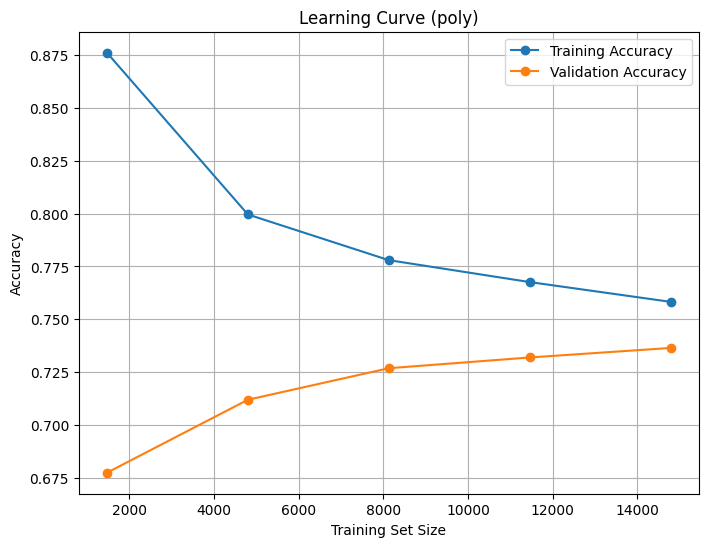

In [315]:
learning_curve_svc(svc_poly_c, x_train, y_train)

In [316]:
svc_rbf = SVC(kernel='rbf' , gamma=0.1)
svc_rbf.fit(x_train , y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [317]:
print(f"Score of Train: {svc_rbf.score(x_train , y_train)}")
print(f"Score of Test: {svc_rbf.score(x_test , y_test)}")

Score of Train: 0.7670349492671927
Score of Test: 0.7417027417027418



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.78      0.57      0.66      1159
         1.0       0.81      0.81      0.81      3288
         2.0       0.56      0.71      0.63      1097

    accuracy                           0.74      5544
   macro avg       0.71      0.70      0.70      5544
weighted avg       0.75      0.74      0.74      5544


===== Confusion Matrix =====
[[ 659  315  185]
 [ 186 2676  426]
 [   5  315  777]]


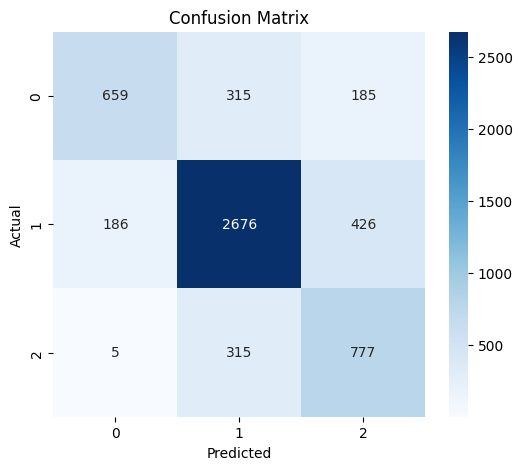

In [318]:
evaluate_model_classification(svc_rbf, x_test, y_test)

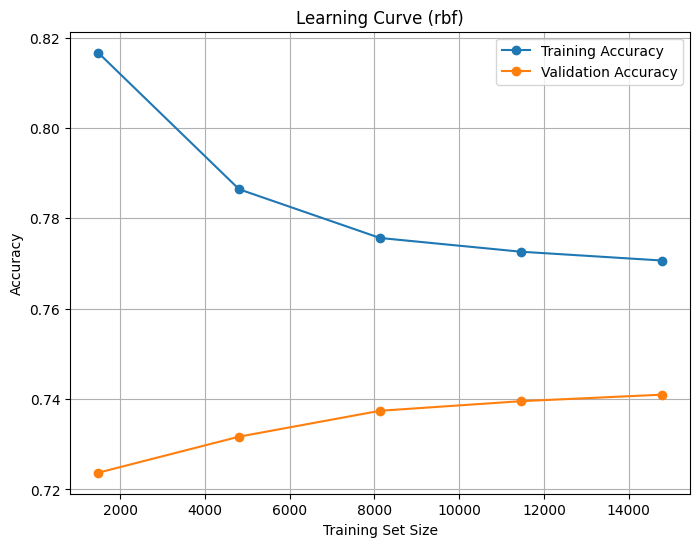

In [319]:
learning_curve_svc(svc_rbf, x_train, y_train)

**Interpretation**
1. **Kernel = Linear (Scores: Train ≈ 0.714, Test ≈ 0.713)**

underfitting because the classes are likely not linearly separable.

2. **Kernel = Poly (Train ≈ 0.74, Test ≈ 0.73)**

Higher train accuracy than linear: model can fit non-linear patterns.

Test accuracy is lower than train: some mild overfitting. However, may not fit complex enough relationships in the data.

3. **Kernel = Poly, C = 5, degree = 3, coef0 = 0.05 (Train ≈ 0.75, Test ≈ 0.74)**

Increasing C reduces regularization so model fits training data better.

 Therefore, train accuracy increases.

4. **Kernel = RBF, gamma = 0.1 (Train ≈ 0.76, Test ≈ 0.74)**

Test accuracy likely improves compared to high-gamma RBF where gamma=10 led to severe overfitting.

- **Result:** Kernel = RBF, gamma = 0.1 is the best combination, as it provided the best test accuracy, which is good for generalization. Although, the second combination has small overfitting gap but lower test accuracy. Additionally, RBF kernel SVC fit more complex relationships in the data than polynomial kernel SVC.

- These results highlights the need for class balancing and feature selection.

#### 3.4 Decision Trees

- Grid Search for hyperparameters.
- max_depth Curve

In [320]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

def grid_search_dt_full(X_train, y_train, X_test, y_test, param_grid, cv=5, scoring='accuracy'):

    dt = DecisionTreeClassifier(random_state=42)
    grid = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    print("Best hyperparameters:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    
    # Extract max_depth scores from cv results
    max_depth_values = sorted(list(set([p['max_depth'] for p in grid.cv_results_['params']])))
    train_scores_mean = []
    val_scores_mean = []
    
    for depth in max_depth_values:
        # find all entries in cv results_ with this max_depth
        mask = [p['max_depth'] == depth for p in grid.cv_results_['params']]
        train_scores_mean.append(np.mean(grid.cv_results_['mean_train_score'][mask]))
        val_scores_mean.append(np.mean(grid.cv_results_['mean_test_score'][mask]))
    
    # Plot max_depth curve
    plt.figure(figsize=(8,6))
    plt.plot(max_depth_values, train_scores_mean, marker='o', label='Training Accuracy')
    plt.plot(max_depth_values, val_scores_mean, marker='o', label='Validation Accuracy')
    plt.title('Decision Tree Accuracy vs max_depth')
    plt.xlabel('max_depth')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Fit final best model
    best_model = grid.best_estimator_
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    print("Accuracy on Training Set:", accuracy_score(y_train, y_train_pred))
    print("Accuracy on Test Set:", accuracy_score(y_test, y_test_pred))
    
    return best_model


Best hyperparameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.7414205186020293


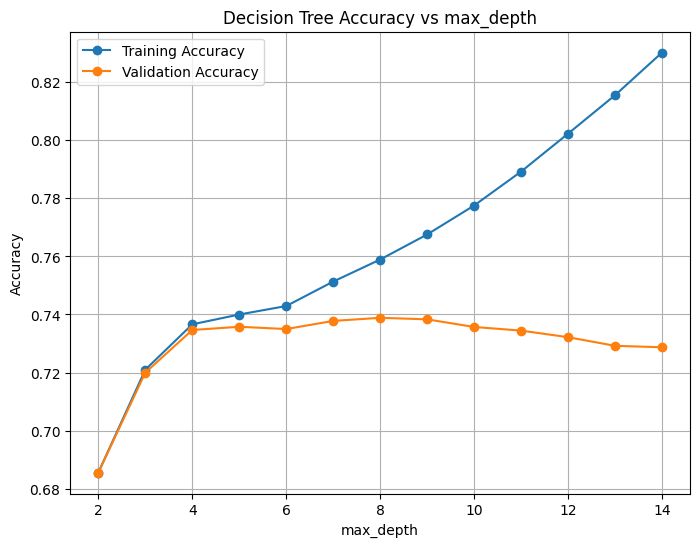

Accuracy on Training Set: 0.7567981961668546
Accuracy on Test Set: 0.7402597402597403


In [321]:
param_grid = {
    'max_depth': range(2, 15),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

best_dt = grid_search_dt_full(x_train, y_train, x_test, y_test, param_grid)


In [322]:
DT = DecisionTreeClassifier(max_depth=8 , random_state=42, min_samples_leaf=1 , min_samples_split=2 , criterion='entropy')
DT.fit(x_train , y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [323]:
print(f"Score of Train: {DT.score(x_train , y_train)}")
print(f"Score of Test: {DT.score(x_test , y_test)}")

Score of Train: 0.7567981961668546
Score of Test: 0.7402597402597403


Classification Report


===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.74      0.60      0.66      1159
         1.0       0.82      0.80      0.81      3288
         2.0       0.56      0.73      0.63      1097

    accuracy                           0.74      5544
   macro avg       0.71      0.71      0.70      5544
weighted avg       0.75      0.74      0.74      5544


===== Confusion Matrix =====
[[ 691  278  190]
 [ 231 2615  442]
 [  10  289  798]]


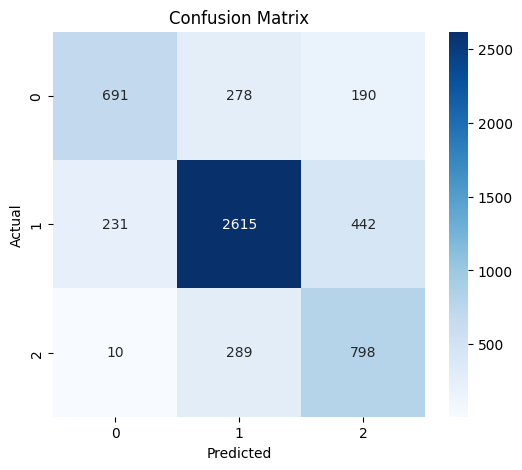

In [324]:
evaluate_model_classification(DT, x_test, y_test)

How Decision Trees Work?

The plot shows how the Decision Tree makes decisions by splitting the data based on features. Each node represents a rule, and each branch leads to further splits. Predicting a class at the leaves. 

Features closer to the root are more important because they split the data earlier. The colors indicate which class dominates in each node.

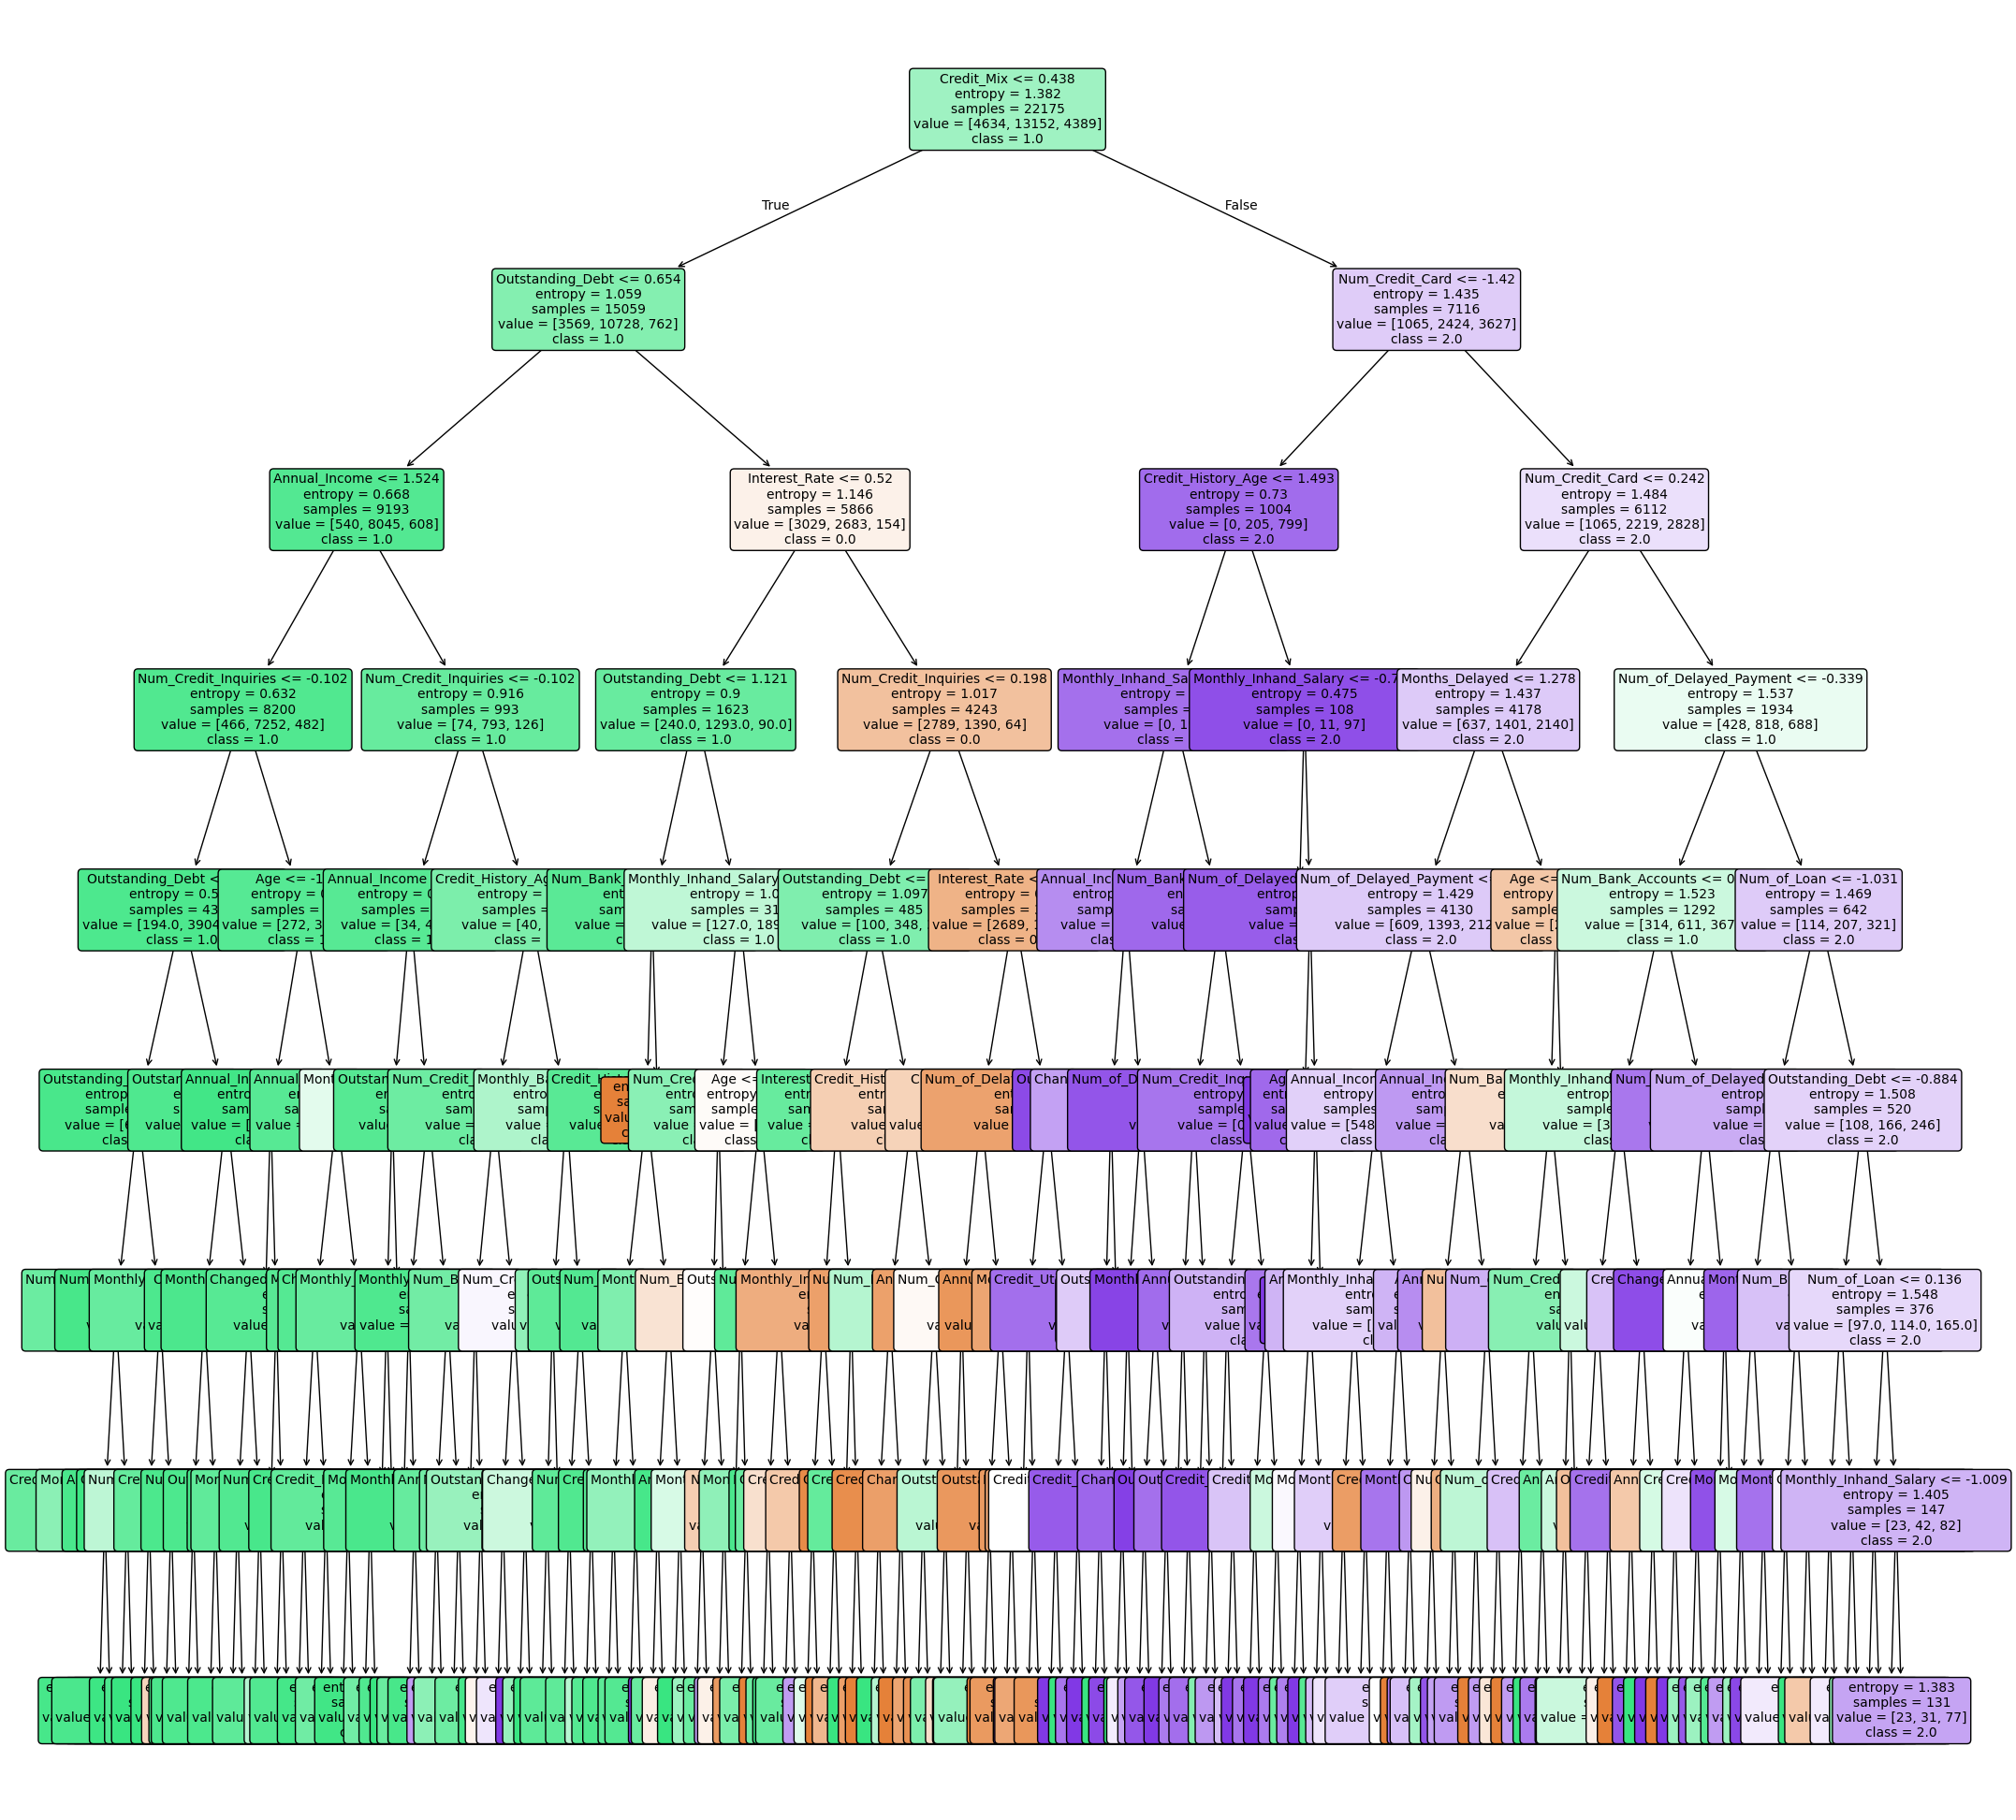

In [325]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,25))
plot_tree(
    DT, 
    feature_names=x.columns, 
    class_names=[str(c) for c in DT.classes_],
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.show()


Learning Curve

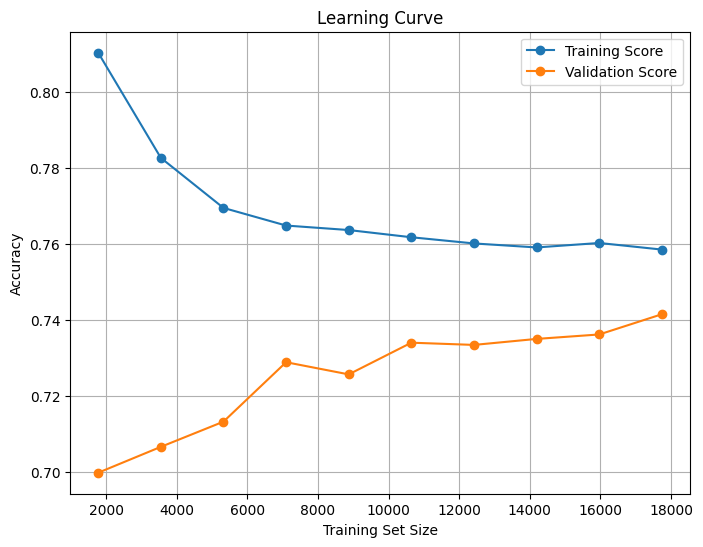

In [326]:
plot_learning_curve(DT,x_train, y_train)

- The model generalizes well to unseen data.
- Based on the learning curve, the Decision Tree model shows a good fit with both training and validation accuracies being relatively high and close to each other. This indicates that the model is neither overfitting nor underfitting the data significantly.

ROC Curve

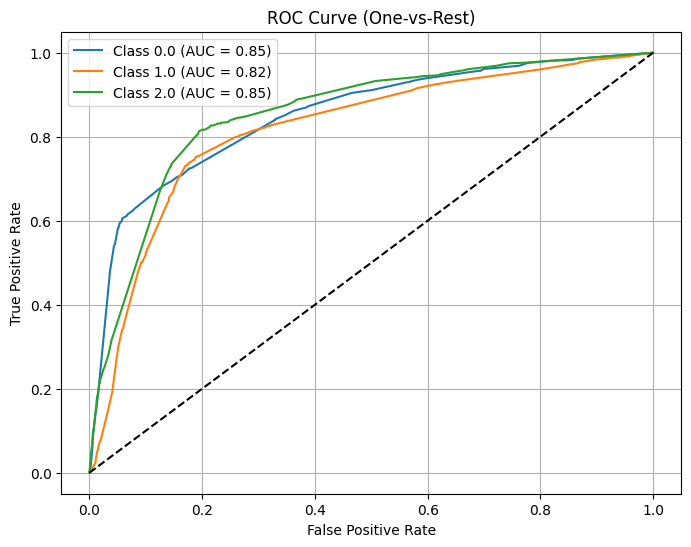

In [327]:
plot_multiclass_roc(DT, x_test, y_test)

**Interpretation**
- Overall accuracy 74%
- Good fit model
- Most confusion occurs between Poor and Standard and between Standard and Good.
- Good class is indeed under-predicted compared to Standard.
- Misclassification between Poor and Good directly is relatively low.

#### ROC for all 4 models

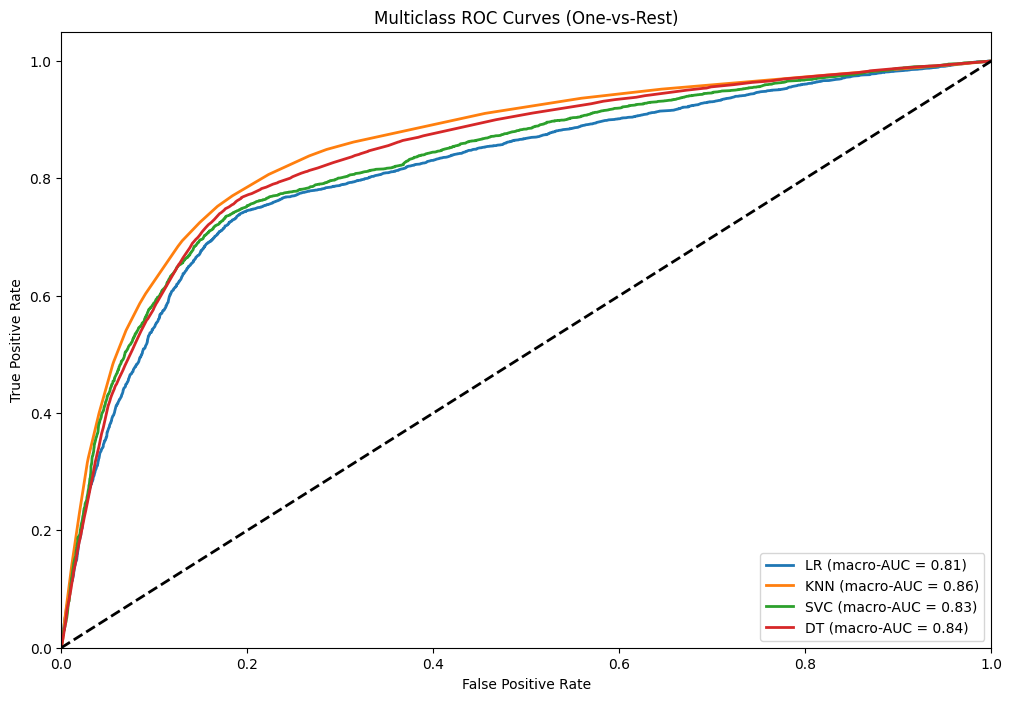

In [328]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize the true labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# List of models
models = {'LR': lr, 'KNN': knnc, 'SVC': svc_rbf, 'DT': DT}

plt.figure(figsize=(12, 8))

for name, model in models.items():
    # Get predicted probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)
    else:
        y_score = model.decision_function(x_test)
    
    # Compute macro-average ROC
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    # Macro-average TPR
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc = auc(all_fpr, mean_tpr)
    
    plt.plot(all_fpr, mean_tpr, lw=2, label=f'{name} (macro-AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()


Best Model:

### 4. Handling Class Imbalance

**SMOTE: Synthetic Minority Over-sampling Technique**

- Pick a minority-class sample (e.g., a “Poor” credit score example).
- Find its k nearest minority neighbors (default: 5).
- Randomly choose one neighbor.
- Create a synthetic sample by interpolating between the original point and the neighbor.
- So the new point lies somewhere on the line between two real minority samples, making it realistic.

In [253]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to training data
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

#### 4.1 Logistic Regression

In [254]:
lr = LogisticRegression(C=1)

lr.fit(x_train_sm, y_train_sm)

print(f"Score of Train: {lr.score(x_train_sm , y_train_sm)}")
print(f"Score of Test: {lr.score(x_test , y_test)}")

Score of Train: 0.7046076642335767
Score of Test: 0.676046176046176



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.54      0.63      0.58      1159
         1.0       0.86      0.65      0.74      3288
         2.0       0.51      0.82      0.63      1097

    accuracy                           0.68      5544
   macro avg       0.64      0.70      0.65      5544
weighted avg       0.73      0.68      0.69      5544


===== Confusion Matrix =====
[[ 726  170  263]
 [ 576 2127  585]
 [  39  163  895]]


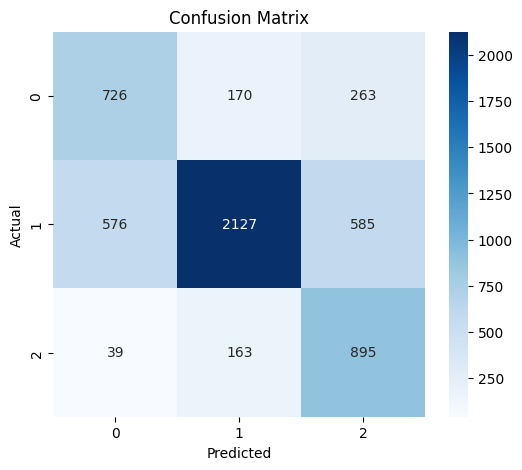

In [255]:
evaluate_model_classification(lr, x_test, y_test)

**Interpretation**

- Before SMOTE, the model favors majority class 1. 
- After SMOTE: Class 0 recall improved from 0.48 to 0.63
- Class 2 recall improved from 0.67 to 0.82
- Majority class 1 Recall dropped from 0.82 to 0.65

#### 4.2 KNN

In [256]:
knnc =KNeighborsClassifier(n_neighbors=10)
knnc.fit(x_train_sm , y_train_sm)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [257]:
print(f"Score of Train: {knnc.score(x_train_sm , y_train_sm)}")
print(f"Score of Test: {knnc.score(x_test , y_test)}")

Score of Train: 0.8587540551500406
Score of Test: 0.6868686868686869



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.56      0.79      0.65      1159
         1.0       0.88      0.62      0.73      3288
         2.0       0.54      0.78      0.64      1097

    accuracy                           0.69      5544
   macro avg       0.66      0.73      0.67      5544
weighted avg       0.74      0.69      0.69      5544


===== Confusion Matrix =====
[[ 920  132  107]
 [ 647 2035  606]
 [  88  156  853]]


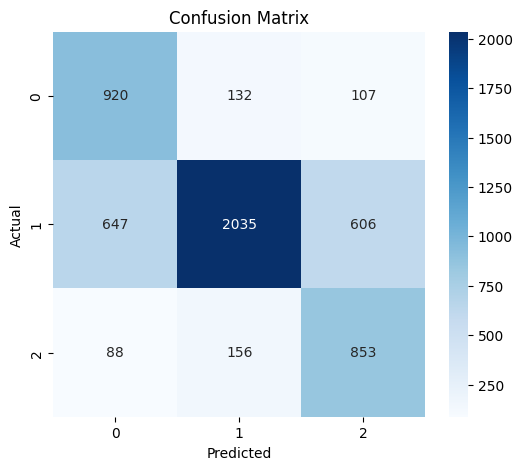

In [258]:
evaluate_model_classification(knnc, x_test, y_test)

**Interpretation**
- Majority class 1 has strong recall while other classes has weak recall.
- Class 0 recall improved: 0.63 to 0.79
- Class 2 recall improved: 0.62 to 0.78
- Class 1 recall worsened: 0.78 to 0.62

#### 4.3 SVC

In [259]:
svc_rbf = SVC(kernel='rbf' , gamma=0.1)
svc_rbf.fit(x_train_sm , y_train_sm)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [260]:
print(f"Score of Train: {svc_rbf.score(x_train_sm , y_train_sm)}")
print(f"Score of Test: {svc_rbf.score(x_test , y_test)}")

Score of Train: 0.7981295620437956
Score of Test: 0.737914862914863



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.69      0.68      0.68      1159
         1.0       0.87      0.74      0.80      3288
         2.0       0.55      0.79      0.65      1097

    accuracy                           0.74      5544
   macro avg       0.70      0.74      0.71      5544
weighted avg       0.77      0.74      0.74      5544


===== Confusion Matrix =====
[[ 783  194  182]
 [ 316 2439  533]
 [  43  185  869]]


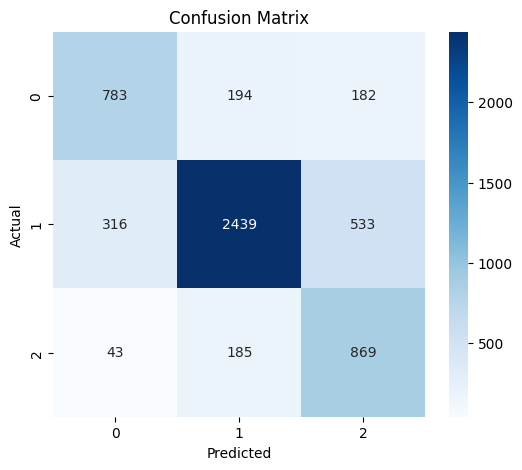

In [261]:
evaluate_model_classification(svc_rbf, x_test, y_test)

**Interpretation**
- The classes are slightly more balanced, recall and f1 score improved. However, it caused overfitting.

#### 4.4 Decision Trees

In [271]:
DT = DecisionTreeClassifier(max_depth=8 , random_state=42, min_samples_leaf=1 , min_samples_split=2 , criterion='entropy')

DT.fit(x_train_sm , y_train_sm)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [284]:
print(f"Score of Train: {DT.score(x_train_sm , y_train_sm)}")
print(f"Score of Test: {DT.score(x_test , y_test)}")

Score of Train: 0.7563108272506083
Score of Test: 0.7233044733044733



===== Classification Report (Test Data) =====
              precision    recall  f1-score   support

         0.0       0.70      0.61      0.65      1159
         1.0       0.86      0.74      0.79      3288
         2.0       0.52      0.79      0.62      1097

    accuracy                           0.72      5544
   macro avg       0.69      0.71      0.69      5544
weighted avg       0.75      0.72      0.73      5544


===== Confusion Matrix =====
[[ 712  207  240]
 [ 281 2435  572]
 [  29  205  863]]


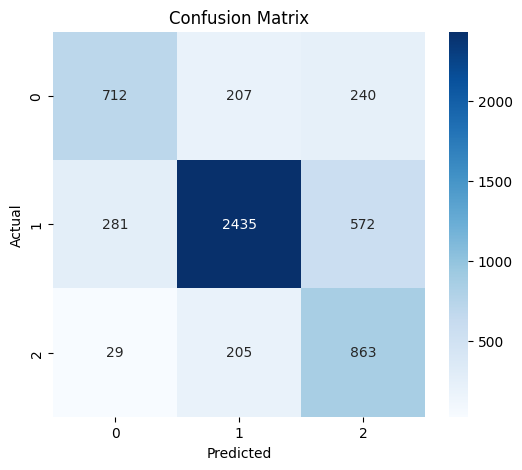

In [285]:
evaluate_model_classification(DT, x_test, y_test)

**Interpretation**
- The tree is less biased toward the majority class due to SMOTE.
- The model learns to genealize well for class 0 and 2. However, the accuracy dropped.

- **why Accuracy dropped?**

SMOTE makes the model more balanced, not necessarily higher accuracy.
- Before SMOTE:
1. Data is imbalanced 
2. The model mostly predicts the majority class (standard). Which results High accuracy but bad performance for minority classes. 

- After SMOTE: 
1. The dataset is balanced 
2. The model is forced to learn minority classes. 
3. It predicts minority classes better. But overall accuracy can drop because it doesn't always guess the majority class anymore.

### 5. Conclusion

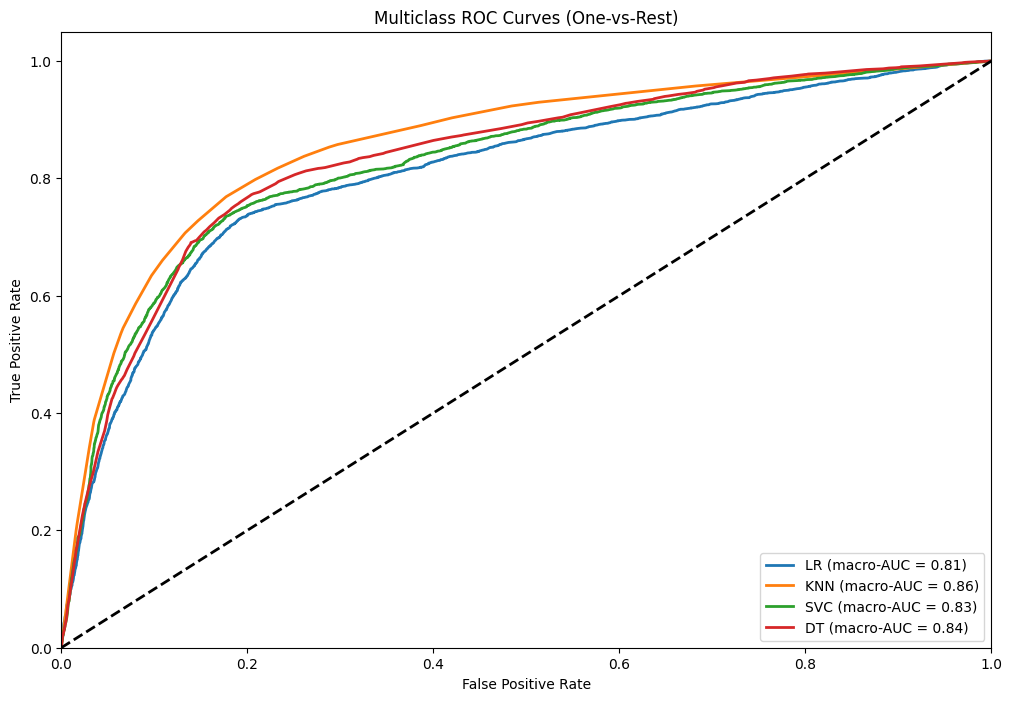

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize the true labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# List of models
models = {'LR': lr, 'KNN': knnc, 'SVC': svc_rbf, 'DT': DT}

plt.figure(figsize=(12, 8))

for name, model in models.items():
    # Get predicted probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)
    else:
        y_score = model.decision_function(x_test)
    
    # Compute macro-average ROC
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    # Macro-average TPR
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc = auc(all_fpr, mean_tpr)
    
    plt.plot(all_fpr, mean_tpr, lw=2, label=f'{name} (macro-AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()


- KNN balances Poor, Standard, and Good classes best.

- Imbalanced data favors the majority class in F1/accuracy but may not drastically affect AUC.

- SMOTE helps minority class recall, but may slightly reduce weighted F1.

- While KNN has the highest AUC, SVC-RBF is overall best because it balances F1, recall, and discrimination across all classes, making it more reliable for practical use.